# Additional Task 2: Tolstoy & Dostoevsky — Paragraph Similarity

1. Split both novels from the previous assignment into paragraphs.
2. Using BM25/TF-IDF representations, find the most similar paragraphs within each novel and across two novels.
3. Which IDF scores would you use for this task? Analyze the results.

In [20]:
import re
import html as html_lib

import numpy as np
import pandas as pd
import requests
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

## 1. Загрузка текстов

In [21]:
def fetch_text_from_azlib(urls):
    """Скачивает и очищает текст с az.lib.ru."""
    full_text = []
    for url in urls:
        resp = requests.get(url)
        resp.encoding = resp.apparent_encoding
        html = resp.text
        html = re.split(r'ПЕЧАТНЫЕ ВАРИАНТЫ|ВАРИАНТЫ И РАЗНОЧТЕНИЯ|КОММЕНТАРИИ', html)[0]
        text = re.sub(r"<br[^>]*>", "\n", html, flags=re.IGNORECASE)
        text = re.sub(r"<[^>]+>", "", text)
        text = html_lib.unescape(text)
        full_text.append(text)
    return "\n".join(full_text)


tolstoy_urls = [
    "http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0040.shtml",
    "http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0050.shtml",
    "http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0060.shtml",
    "http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0070.shtml",
]

dostoevsky_urls = [
    "http://az.lib.ru/d/dostoewskij_f_m/text_0100.shtml",
    "http://az.lib.ru/d/dostoewskij_f_m/text_0110.shtml",
    "http://az.lib.ru/d/dostoewskij_f_m/text_0120.shtml",
    "http://az.lib.ru/d/dostoewskij_f_m/text_0130.shtml",
]

tolstoy_raw = fetch_text_from_azlib(tolstoy_urls)
dostoevsky_raw = fetch_text_from_azlib(dostoevsky_urls)

print(f"Толстой: {len(tolstoy_raw):,} символов")
print(f"Достоевский: {len(dostoevsky_raw):,} символов")

Толстой: 3,030,381 символов
Достоевский: 1,842,913 символов


## 2. Разбиение на абзацы

In [22]:
def split_into_paragraphs(text, min_words=10):
    """Делит текст на абзацы и убирает слишком короткие."""
    paragraphs = re.split(r"\n+", text)
    result = []
    for p in paragraphs:
        p = re.sub(r"\s+", " ", p).strip()
        if len(p.split()) >= min_words:
            result.append(p)
    return result


tolstoy_paragraphs = split_into_paragraphs(tolstoy_raw)
dostoevsky_paragraphs = split_into_paragraphs(dostoevsky_raw)

print(f"Толстой: {len(tolstoy_paragraphs)} абзацев")
print(f"Достоевский: {len(dostoevsky_paragraphs)} абзацев")

t_lens = [len(p.split()) for p in tolstoy_paragraphs]
d_lens = [len(p.split()) for p in dostoevsky_paragraphs]

print(f"\nТолстой — длина абзацев (слова): min={min(t_lens)}, max={max(t_lens)}, "
      f"mean={np.mean(t_lens):.1f}, median={np.median(t_lens):.1f}")
print(f"Достоевский — длина абзацев (слова): min={min(d_lens)}, max={max(d_lens)}, "
      f"mean={np.mean(d_lens):.1f}, median={np.median(d_lens):.1f}")

Толстой: 9431 абзацев
Достоевский: 3925 абзацев

Толстой — длина абзацев (слова): min=10, max=892, mean=48.7, median=31.0
Достоевский — длина абзацев (слова): min=10, max=3459, mean=75.1, median=29.0


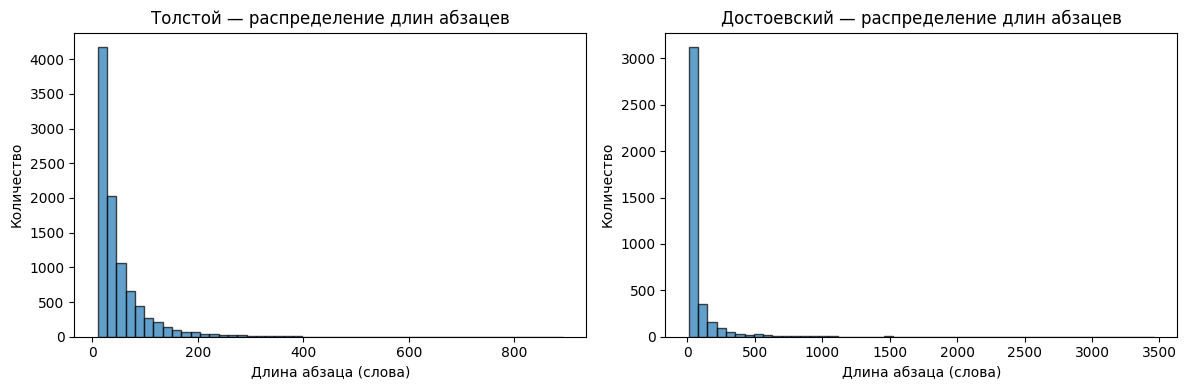

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(t_lens, bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Длина абзаца (слова)")
axes[0].set_ylabel("Количество")
axes[0].set_title("Толстой — распределение длин абзацев")

axes[1].hist(d_lens, bins=50, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Длина абзаца (слова)")
axes[1].set_ylabel("Количество")
axes[1].set_title("Достоевский — распределение длин абзацев")

plt.tight_layout()
plt.show()

## 3. Поиск похожих абзацев с TF-IDF

### Какие IDF использовать?

Выбор IDF-словаря зависит от задачи:

1. **Внутри одного романа**: IDF считаем по абзацам этого же романа. Тогда общие для романа слова (имена главных героев, частотные слова) получат низкий IDF, а редкие тематические слова — высокий. Это выделяет тематическую уникальность абзацев.

2. **Между романами**: IDF нужно считать по объединённому корпусу обоих романов. Если бы мы считали IDF отдельно для каждого романа, то имена персонажей одного романа получали бы завышенный IDF в другом (т.к. они там не встречаются), и сходство определялось бы случайными совпадениями имён, а не содержательной близостью.

**Вывод**: для поиска внутри романа — IDF по этому роману; для сравнения между романами — IDF по объединённому корпусу.

In [24]:
def tokenize_text(text):
    """Токенизирует текст в нижнем регистре."""
    return re.findall(r"[а-яёa-z0-9]+", text.lower())


def tokenize_for_tfidf(text):
    return " ".join(tokenize_text(text))


tolstoy_tokenized = [tokenize_for_tfidf(p) for p in tolstoy_paragraphs]
dostoevsky_tokenized = [tokenize_for_tfidf(p) for p in dostoevsky_paragraphs]
all_tokenized = tolstoy_tokenized + dostoevsky_tokenized

print(f"Толстой: {len(tolstoy_tokenized)} абзацев")
print(f"Достоевский: {len(dostoevsky_tokenized)} абзацев")
print(f"Объединённый корпус: {len(all_tokenized)} абзацев")

Толстой: 9431 абзацев
Достоевский: 3925 абзацев
Объединённый корпус: 13356 абзацев


### 3.1 TF-IDF: похожие абзацы внутри каждого романа

In [25]:
def find_most_similar_pairs_tfidf(paragraphs_tokenized, paragraphs_raw, top_k=10):
    """Ищет самые похожие пары абзацев через TF-IDF."""
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(paragraphs_tokenized)
    sim_matrix = cosine_similarity(tfidf_matrix)

    # Обнуляем диагональ и нижний треугольник
    np.fill_diagonal(sim_matrix, 0)
    sim_matrix = np.triu(sim_matrix)

    # Берём top-k пар
    flat_indices = np.argsort(sim_matrix.ravel())[::-1][:top_k]
    pairs = []
    n = sim_matrix.shape[0]
    for idx in flat_indices:
        i, j = divmod(idx, n)
        score = sim_matrix[i, j]
        if score == 0:
            break
        pairs.append({
            "para_i": i,
            "para_j": j,
            "cosine_sim": round(score, 4),
            "text_i": " ".join(paragraphs_raw[i].split()[:30]) + "...",
            "text_j": " ".join(paragraphs_raw[j].split()[:30]) + "...",
        })
    return pd.DataFrame(pairs)


print("=== Толстой: самые похожие абзацы внутри романа (TF-IDF) ===")
tolstoy_similar_tfidf = find_most_similar_pairs_tfidf(tolstoy_tokenized, tolstoy_paragraphs)
tolstoy_similar_tfidf

=== Толстой: самые похожие абзацы внутри романа (TF-IDF) ===


,para_i,para_j,cosine_sim,text_i,text_j
0,4937,7368,1.0000,Полного собрания сочинений Л. Н. Толстого можн...,Полного собрания сочинений Л. Н. Толстого можн...
1,2537,7368,1.0000,Полного собрания сочинений Л. Н. Толстого можн...,Полного собрания сочинений Л. Н. Толстого можн...
2,0,4937,1.0000,Полного собрания сочинений Л. Н. Толстого можн...,Полного собрания сочинений Л. Н. Толстого можн...
3,0,7368,1.0000,Полного собрания сочинений Л. Н. Толстого можн...,Полного собрания сочинений Л. Н. Толстого можн...
4,2537,4937,1.0000,Полного собрания сочинений Л. Н. Толстого можн...,Полного собрания сочинений Л. Н. Толстого можн...
5,0,2537,1.0000,Полного собрания сочинений Л. Н. Толстого можн...,Полного собрания сочинений Л. Н. Толстого можн...
6,7346,7791,0.8341,825 Ха -- ха -- ха!.. А вот сказал штуку....,"-- Ха, ха, ха! Ай да Николай Иванович! ха, ха,..."
7,7791,7952,0.8190,"-- Ха, ха, ха! Ай да Николай Иванович! ха, ха,...","-- Ха, ха, ха! -- смеялся Пьер. И он проговори..."
8,7346,7952,0.7346,825 Ха -- ха -- ха!.. А вот сказал штуку....,"-- Ха, ха, ха! -- смеялся Пьер. И он проговори..."
9,6180,6186,0.7340,"""Вице-король завладеет деревней692 и перейдет ...",Четвертое: Вице-король овладеет деревнею (Боро...


In [26]:
print("=== Достоевский: самые похожие абзацы внутри романа (TF-IDF) ===")
dostoevsky_similar_tfidf = find_most_similar_pairs_tfidf(dostoevsky_tokenized, dostoevsky_paragraphs)
dostoevsky_similar_tfidf

=== Достоевский: самые похожие абзацы внутри романа (TF-IDF) ===


,para_i,para_j,cosine_sim,text_i,text_j
0,462,1729,0.9849,"-- Я ведь не знаю, не знаю... Может быть не уб...","""Я ведь не знаю, не знаю"", сказал он тогда; ""м..."
1,622,624,0.6756,"-- Ты будешь с нею счастлив, но может быть... ...","-- Нет, может быть, ты будешь ее вечно любить,..."
2,1891,1895,0.6709,"-- Стой, Трифон Борисыч, -- начал Митя, -- пре...","-- Стой, молчи, Трифон Борисыч, говори теперь ..."
3,435,629,0.6266,"-- Сказать ей, что я больше к ней не приду ник...","-- Он приказал вам... кланяться, и что больше ..."
4,2766,2777,0.6183,"-- Ну, брат, твоя Жучка -- фью! Пропала твоя Ж...",-- Жучка! Так это-то Жучка? -- выкрикивал он б...
5,3061,3064,0.6181,"-- Да, да! Вы мою мысль сказали, любят, все лю...","-- Любят, все любят! Все говорят, что это ужас..."
6,3017,3018,0.5777,-- А стало быть от него слышали! Что ж он бран...,"-- Да, он бранит, но ведь он всех бранит. Но з..."
7,2697,2698,0.5670,"-- А на кой ляд мне твово Чижова, люди добрые,...","-- А я почем знаю, на кой те ляд Чижова...."
8,1891,1898,0.5528,"-- Стой, Трифон Борисыч, -- начал Митя, -- пре...","-- Стой, Трифон Борисыч, стой, душа, сам решу...."
9,2645,2777,0.5488,-- Нельзя Жучку. Жучка не существует. Жучка ис...,-- Жучка! Так это-то Жучка? -- выкрикивал он б...


### 3.2 TF-IDF: похожие абзацы между романами

IDF считаем по объединённому корпусу обоих романов.

In [27]:
# Обучаем на объединённом корпусе
vectorizer_combined = TfidfVectorizer()
tfidf_combined = vectorizer_combined.fit_transform(all_tokenized)

n_t = len(tolstoy_tokenized)
n_d = len(dostoevsky_tokenized)

tfidf_tolstoy = tfidf_combined[:n_t]
tfidf_dostoevsky = tfidf_combined[n_t:]

# Сходство между романами
cross_sim = cosine_similarity(tfidf_tolstoy, tfidf_dostoevsky)

# Топ-10 пар между романами
flat_indices = np.argsort(cross_sim.ravel())[::-1][:10]
cross_pairs = []
for idx in flat_indices:
    i, j = divmod(idx, n_d)
    score = cross_sim[i, j]
    cross_pairs.append({
        "tolstoy_para": i,
        "dostoevsky_para": j,
        "cosine_sim": round(score, 4),
        "tolstoy_text": " ".join(tolstoy_paragraphs[i].split()[:30]) + "...",
        "dostoevsky_text": " ".join(dostoevsky_paragraphs[j].split()[:30]) + "...",
    })

print("Самые похожие абзацы между романами (TF-IDF, IDF по объединённому корпусу)")
cross_tfidf_df = pd.DataFrame(cross_pairs)
cross_tfidf_df

Самые похожие абзацы между романами (TF-IDF, IDF по объединённому корпусу)


,tolstoy_para,dostoevsky_para,cosine_sim,tolstoy_text,dostoevsky_text
0,828,3402,0.6061,"-- И скоро она родит? -- и, с упреком покачав ...","-- Продолжай дальше, -- сказал он ему, -- прод..."
1,955,2910,0.5668,"-- Ну, чтò ""ваше превосходительство""? Ваше пре...","-- Ваше превосходительство, ради Христа! -- ис..."
2,4324,2550,0.5647,"Соня слышала эти слова, и слышала, как Наташа ...","На что Грушенька объявила, что слышала и при л..."
3,8707,3050,0.5522,"-- Неправда, неправда, -- закричал Пьер. -- Я ...","-- Неправда, неправда, пусть есть дети, но я н..."
4,8759,622,0.5490,"-- Нет, этого не может быть! Как я счастлив! Н...","-- Ты будешь с нею счастлив, но может быть... ..."
5,7791,1936,0.5330,"-- Ха, ха, ха! Ай да Николай Иванович! ха, ха,...",-- Врет? -- рассмеялся он своим коротким дерев...
6,7791,690,0.4911,"-- Ха, ха, ха! Ай да Николай Иванович! ха, ха,...",-- Ха-ха-ха! Ты не ожидал? Я думаю: где тебя п...
7,8759,624,0.4792,"-- Нет, этого не может быть! Как я счастлив! Н...","-- Нет, может быть, ты будешь ее вечно любить,..."
8,7791,1619,0.4784,"-- Ха, ха, ха! Ай да Николай Иванович! ха, ха,...",-- Гениальная мысль! -- восторженно перебил Ми...
9,7952,1936,0.4773,"-- Ха, ха, ха! -- смеялся Пьер. И он проговори...",-- Врет? -- рассмеялся он своим коротким дерев...


## 4. Поиск похожих абзацев с BM25

BM25 — это ассиметричная функция: один абзац выступает «запросом», другой — «документом». Для поиска наиболее похожих пар используем каждый абзац как запрос к коллекции.

In [28]:
def find_most_similar_pairs_bm25(paragraphs_tokenized, paragraphs_raw, top_k=10):
    """Ищет самые похожие пары абзацев через BM25."""
    tokenized = [p.split() for p in paragraphs_tokenized]
    bm25 = BM25Okapi(tokenized)

    # Сначала быстро отбираем кандидатов через TF-IDF,
    # затем пересчитываем BM25 только для них.
    n = len(tokenized)
    if n < 2:
        return pd.DataFrame(columns=["para_i", "para_j", "bm25_score", "text_i", "text_j"])

    candidate_k = min(max(top_k * 20, 50), n - 1)
    pair_scores = []
    tfidf_matrix = TfidfVectorizer().fit_transform(paragraphs_tokenized)

    for i in range(n):
        candidate_scores = cosine_similarity(tfidf_matrix[i], tfidf_matrix).ravel()
        candidate_scores[i] = 0
        candidate_ids = np.argpartition(candidate_scores, -candidate_k)[-candidate_k:]
        candidate_ids = [j for j in candidate_ids if j != i and candidate_scores[j] > 0]
        if not candidate_ids:
            continue

        scores = bm25.get_batch_scores(tokenized[i], candidate_ids)
        for local_idx in np.argsort(scores)[::-1][:3]:  # оставляем top-3 для каждого запроса
            j = candidate_ids[local_idx]
            score = scores[local_idx]
            if score > 0 and i < j:  # убираем дубликаты
                pair_scores.append((i, j, score))

    # Сортируем и удаляем дубликаты
    pair_scores.sort(key=lambda x: -x[2])
    seen = set()
    results = []
    for i, j, score in pair_scores:
        key = (min(i, j), max(i, j))
        if key not in seen:
            seen.add(key)
            results.append({
                "para_i": i,
                "para_j": j,
                "bm25_score": round(score, 4),
                "text_i": " ".join(paragraphs_raw[i].split()[:30]) + "...",
                "text_j": " ".join(paragraphs_raw[j].split()[:30]) + "...",
            })
            if len(results) >= top_k:
                break
    return pd.DataFrame(results)


print("=== Толстой: самые похожие абзацы внутри романа (BM25) ===")
tolstoy_similar_bm25 = find_most_similar_pairs_bm25(tolstoy_tokenized, tolstoy_paragraphs)
tolstoy_similar_bm25

=== Толстой: самые похожие абзацы внутри романа (BM25) ===


,para_i,para_j,bm25_score,text_i,text_j
0,3133,4984,1236.2497,"""Voilà le premier acte. Aux suivants l'intêret...","""Monsieur mon frère. J'ai appris hier que malg..."
1,784,3133,948.5893,"""La nouvelle de la mort du comte Безухов nous ...","""Voilà le premier acte. Aux suivants l'intêret..."
2,784,785,946.4750,"""La nouvelle de la mort du comte Безухов nous ...","""Mon père ne m'a pas parlé du pretendant, mais..."
3,778,784,890.2741,"""Tout Moscou ne parle que guerre.216 L'un de m...","""La nouvelle de la mort du comte Безухов nous ..."
4,778,785,863.3501,"""Tout Moscou ne parle que guerre.216 L'un de m...","""Mon père ne m'a pas parlé du pretendant, mais..."
5,778,779,855.2044,"""Tout Moscou ne parle que guerre.216 L'un de m...","""Je vous avoue, que je comprends très peu tout..."
6,785,3133,644.7661,"""Mon père ne m'a pas parlé du pretendant, mais...","""Voilà le premier acte. Aux suivants l'intêret..."
7,779,784,503.9725,"""Je vous avoue, que je comprends très peu tout...","""La nouvelle de la mort du comte Безухов nous ..."
8,4369,5705,500.6428,В последнее время в Москве эта внутренняя жизн...,Княжне Марье живо представилось положение m-ll...
9,779,785,498.0700,"""Je vous avoue, que je comprends très peu tout...","""Mon père ne m'a pas parlé du pretendant, mais..."


In [29]:
print("=== Достоевский: самые похожие абзацы внутри романа (BM25) ===")
dostoevsky_similar_bm25 = find_most_similar_pairs_bm25(dostoevsky_tokenized, dostoevsky_paragraphs)
dostoevsky_similar_bm25

=== Достоевский: самые похожие абзацы внутри романа (BM25) ===


,para_i,para_j,bm25_score,text_i,text_j
0,1218,1414,2277.0026,"Реши же сам, кто был прав: ты или тот, который...","Други мои, просите у бога веселья. Будьте весе..."
1,1218,1419,2261.4113,"Реши же сам, кто был прав: ты или тот, который...",Если же злодейство людей возмутит тебя негодов...
2,1351,1357,1571.5905,"В Петербурге, в кадетском корпусе, пробыл я до...","Выслушал он, смотрит так хорошо на меня: ""Все ..."
3,1349,1407,1478.4492,Остались мы тогда одни с матушкой. Посоветовал...,"Боже, кто говорит, и в народе грех. А пламень ..."
4,1349,1357,1433.2885,Остались мы тогда одни с матушкой. Посоветовал...,"Выслушал он, смотрит так хорошо на меня: ""Все ..."
5,1349,1420,1423.9542,Остались мы тогда одни с матушкой. Посоветовал...,"""Страдание о том, что нельзя уже более любить""..."
6,3735,3757,1014.3103,"И вот он пред своими судьями, пред решителями ...","""Позвольте, господа присяжные, тут жизнь челов..."
7,3755,3756,972.4420,"""Господа присяжные заседатели,-- приступил защ...",За месяц до катастрофы подсудимому были вверен...
8,3760,3764,949.2692,"""Не совокупность только фактов губит моего кли...","""Господа присяжные заседатели, вы помните ту с..."
9,3760,3762,931.0948,"""Не совокупность только фактов губит моего кли...","""Думаете ли вы, господа присяжные, что такие в..."


### 4.1 BM25: похожие абзацы между романами

Строим BM25-индекс по объединённому корпусу (IDF по обоим романам), затем ищем ближайшие пары между романами.

In [32]:
# BM25 на объединённом корпусе
all_tokenized_split = [p.split() for p in all_tokenized]
bm25_combined = BM25Okapi(all_tokenized_split)

n_t = len(tolstoy_tokenized)
n_d = len(dostoevsky_tokenized)

# Сначала быстро отбираем кандидатов другого автора через TF-IDF,
# затем выбираем лучший вариант по BM25 только среди них.
candidate_k_td = min(200, n_d)
candidate_k_dt = min(200, n_t)
cross_bm25_pairs = []

for i in range(n_t):
    candidate_scores = cosine_similarity(tfidf_tolstoy[i], tfidf_dostoevsky).ravel()
    candidate_ids_local = np.argpartition(candidate_scores, -candidate_k_td)[-candidate_k_td:]
    candidate_ids_global = [n_t + j for j in candidate_ids_local if candidate_scores[j] > 0]
    if not candidate_ids_global:
        continue
    scores = bm25_combined.get_batch_scores(all_tokenized_split[i], candidate_ids_global)
    best_idx = int(np.argmax(scores))
    best_j = candidate_ids_global[best_idx] - n_t
    cross_bm25_pairs.append((i, best_j, scores[best_idx]))

# Аналогично ищем со стороны Достоевского
for j in range(n_d):
    candidate_scores = cosine_similarity(tfidf_dostoevsky[j], tfidf_tolstoy).ravel()
    candidate_ids_local = np.argpartition(candidate_scores, -candidate_k_dt)[-candidate_k_dt:]
    candidate_ids_global = [i for i in candidate_ids_local if candidate_scores[i] > 0]
    if not candidate_ids_global:
        continue
    scores = bm25_combined.get_batch_scores(all_tokenized_split[n_t + j], candidate_ids_global)
    best_idx = int(np.argmax(scores))
    best_i = candidate_ids_global[best_idx]
    cross_bm25_pairs.append((best_i, j, scores[best_idx]))

# Сортируем и удаляем дубликаты
cross_bm25_pairs.sort(key=lambda x: -x[2])
seen = set()
cross_results = []
for i, j, score in cross_bm25_pairs:
    key = (i, j)
    if key not in seen:
        seen.add(key)
        cross_results.append({
            "tolstoy_para": i,
            "dostoevsky_para": j,
            "bm25_score": round(score, 4),
            "tolstoy_text": " ".join(tolstoy_paragraphs[i].split()[:30]) + "...",
            "dostoevsky_text": " ".join(dostoevsky_paragraphs[j].split()[:30]) + "...",
        })
        if len(cross_results) >= 10:
            break

print("Самые похожие абзацы между романами (BM25, IDF по объединённому корпусу)")
cross_bm25_df = pd.DataFrame(cross_results)
cross_bm25_df

Самые похожие абзацы между романами (BM25, IDF по объединённому корпусу)


,tolstoy_para,dostoevsky_para,bm25_score,tolstoy_text,dostoevsky_text
0,2974,1218,2037.1060,"-- Он есть, но понять Его трудно, -- заговорил...","Реши же сам, кто был прав: ты или тот, который..."
1,3622,1351,1452.1733,"""Видел сон, от которого проснулся с трепещущим...","В Петербурге, в кадетском корпусе, пробыл я до..."
2,3621,1349,1276.8999,"""Видел сон, будто Иосиф Алексеевич в моем доме...",Остались мы тогда одни с матушкой. Посоветовал...
3,6583,3758,805.9016,"""Солдатом быть, просто солдатом!"" думал Пьер, ...","Повторяю, тут вся логика обвинения: кто же уби..."
4,3204,1188,761.3869,"-- Ну, вот ты хочешь освободить крестьян, -- п...",-- А ты удивительно как умеешь оборачивать сло...
5,1734,377,753.9494,"""Но она глупа, я сам говорил, что она глупа, -...","Тут было одно особенное обстоятельство, которо..."
6,2863,3735,722.5942,"""Ведь он знает, чтò значит для меня этот проиг...","И вот он пред своими судьями, пред решителями ..."
7,3928,3716,689.1495,"В середине лета, княжна Марья получила неожида...","""Но вот третий сын отца современного семейства..."
8,3621,1347,662.7349,"""Видел сон, будто Иосиф Алексеевич в моем доме...","Возлюбленные отцы и учители, родился я в далек..."
9,3928,3760,661.7732,"В середине лета, княжна Марья получила неожида...","""Не совокупность только фактов губит моего кли..."


## 5. Сравнение подходов к IDF

Проверим, как выбор корпуса для IDF влияет на результаты кросс-поиска.

In [33]:
# Вариант 1: IDF по объединённому корпусу
# Вариант 2: IDF по Толстому, поиск абзацев Достоевского

vectorizer_tolstoy_only = TfidfVectorizer()
tfidf_tolstoy_only = vectorizer_tolstoy_only.fit_transform(tolstoy_tokenized)
# Преобразуем Достоевского словарём и IDF Толстого
tfidf_dostoevsky_via_tolstoy = vectorizer_tolstoy_only.transform(dostoevsky_tokenized)

cross_sim_tolstoy_idf = cosine_similarity(tfidf_tolstoy_only, tfidf_dostoevsky_via_tolstoy)

flat_indices = np.argsort(cross_sim_tolstoy_idf.ravel())[::-1][:10]
pairs_tolstoy_idf = []
for idx in flat_indices:
    i, j = divmod(idx, n_d)
    score = cross_sim_tolstoy_idf[i, j]
    pairs_tolstoy_idf.append({
        "tolstoy_para": i,
        "dostoevsky_para": j,
        "cosine_sim": round(score, 4),
        "tolstoy_text": " ".join(tolstoy_paragraphs[i].split()[:25]) + "...",
        "dostoevsky_text": " ".join(dostoevsky_paragraphs[j].split()[:25]) + "...",
    })

print("=== Кросс-поиск с IDF по Толстому ===")
pd.DataFrame(pairs_tolstoy_idf)

=== Кросс-поиск с IDF по Толстому ===


,tolstoy_para,dostoevsky_para,cosine_sim,tolstoy_text,dostoevsky_text
0,828,3402,0.6213,"-- И скоро она родит? -- и, с упреком покачав ...","-- Продолжай дальше, -- сказал он ему, -- прод..."
1,1446,2130,0.5944,-- А ты кто такой? -- вдруг с пьяным бешенство...,-- А ты подлайдак! Мелкий ты подлеченочек; вот...
2,4324,2550,0.5757,"Соня слышала эти слова, и слышала, как Наташа ...","На что Грушенька объявила, что слышала и при л..."
3,7791,690,0.5579,"-- Ха, ха, ха! Ай да Николай Иванович! ха, ха,...",-- Ха-ха-ха! Ты не ожидал? Я думаю: где тебя п...
4,7791,1936,0.5519,"-- Ха, ха, ха! Ай да Николай Иванович! ха, ха,...",-- Врет? -- рассмеялся он своим коротким дерев...
5,3915,654,0.5473,-- Вы ведь давно знаете Безухова? -- спросил о...,-- Но ведь теперь вы же его и спасете. Вы дали...
6,7178,257,0.5428,"-- Простите! -- сказала она шопотом, подняв го...","-- Простите! Простите все! -- проговорил он, о..."
7,8759,622,0.5426,"-- Нет, этого не может быть! Как я счастлив! Н...","-- Ты будешь с нею счастлив, но может быть... ..."
8,955,2910,0.5406,"-- Ну, чтò ""ваше превосходительство""? Ваше пре...","-- Ваше превосходительство, ради Христа! -- ис..."
9,8707,3050,0.5384,"-- Неправда, неправда, -- закричал Пьер. -- Я ...","-- Неправда, неправда, пусть есть дети, но я н..."


In [34]:
# Вариант 3: IDF по Достоевскому
vectorizer_dostoevsky_only = TfidfVectorizer()
tfidf_dostoevsky_only = vectorizer_dostoevsky_only.fit_transform(dostoevsky_tokenized)
tfidf_tolstoy_via_dostoevsky = vectorizer_dostoevsky_only.transform(tolstoy_tokenized)

cross_sim_dostoevsky_idf = cosine_similarity(tfidf_tolstoy_via_dostoevsky, tfidf_dostoevsky_only)

flat_indices = np.argsort(cross_sim_dostoevsky_idf.ravel())[::-1][:10]
pairs_dostoevsky_idf = []
for idx in flat_indices:
    i, j = divmod(idx, n_d)
    score = cross_sim_dostoevsky_idf[i, j]
    pairs_dostoevsky_idf.append({
        "tolstoy_para": i,
        "dostoevsky_para": j,
        "cosine_sim": round(score, 4),
        "tolstoy_text": " ".join(tolstoy_paragraphs[i].split()[:25]) + "...",
        "dostoevsky_text": " ".join(dostoevsky_paragraphs[j].split()[:25]) + "...",
    })

print("Кросс-поиск с IDF по Достоевскому")
pd.DataFrame(pairs_dostoevsky_idf)

Кросс-поиск с IDF по Достоевскому


,tolstoy_para,dostoevsky_para,cosine_sim,tolstoy_text,dostoevsky_text
0,286,2137,0.6156,"-- Не трогай, ты его испугаешь, он убьется. А?...",-- Не трогай меня... -- молящим голосом пролеп...
1,828,3402,0.6130,"-- И скоро она родит? -- и, с упреком покачав ...","-- Продолжай дальше, -- сказал он ему, -- прод..."
2,955,2910,0.5993,"-- Ну, чтò ""ваше превосходительство""? Ваше пре...","-- Ваше превосходительство, ради Христа! -- ис..."
3,7571,3530,0.5947,"-- Oui, sans doute!933--сказал Даву, но что ""д...","-- Не знаю от кого. Но я знал. Знал ли я? Да, ..."
4,1608,598,0.5919,"-- Хорошо, хорошо, -- сказал полковой командир...","-- Да и не хорошо, батюшка, будет, не хорошо с..."
5,8759,622,0.5840,"-- Нет, этого не может быть! Как я счастлив! Н...","-- Ты будешь с нею счастлив, но может быть... ..."
6,8707,3050,0.5635,"-- Неправда, неправда, -- закричал Пьер. -- Я ...","-- Неправда, неправда, пусть есть дети, но я н..."
7,7791,1936,0.5474,"-- Ха, ха, ха! Ай да Николай Иванович! ха, ха,...",-- Врет? -- рассмеялся он своим коротким дерев...
8,6056,3215,0.5366,-- Ты чтó говоришь про ополченье? -- сказал он...,-- Про кого ты говоришь... про Митю? -- в недо...
9,4324,2550,0.5333,"Соня слышала эти слова, и слышала, как Наташа ...","На что Грушенька объявила, что слышала и при л..."


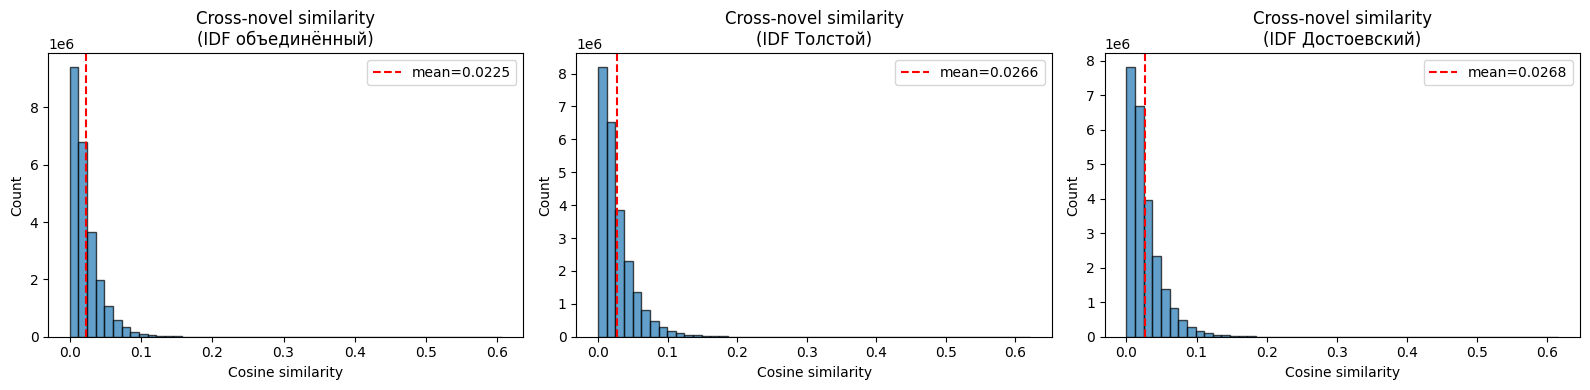

In [35]:
# Сравнение распределений сходства для трёх вариантов IDF
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, sim, title in zip(
    axes,
    [cross_sim, cross_sim_tolstoy_idf, cross_sim_dostoevsky_idf],
    ["IDF объединённый", "IDF Толстой", "IDF Достоевский"],
):
    vals = sim.ravel()
    vals = vals[vals > 0]  # non-zero only
    ax.hist(vals, bins=50, edgecolor="black", alpha=0.7)
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Count")
    ax.set_title(f"Cross-novel similarity\n({title})")
    ax.axvline(np.mean(vals), color="red", linestyle="--", label=f"mean={np.mean(vals):.4f}")
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Анализ: что находят BM25 и TF-IDF?

Сравним, совпадают ли топ-пары по BM25 и TF-IDF.

In [36]:
# Внутри Толстого: пересечение топ-10 пар
tfidf_pairs_t = set(zip(tolstoy_similar_tfidf["para_i"], tolstoy_similar_tfidf["para_j"]))
bm25_pairs_t = set(zip(tolstoy_similar_bm25["para_i"], tolstoy_similar_bm25["para_j"]))
print(f"Толстой: overlap TF-IDF и BM25 топ-10 = {len(tfidf_pairs_t & bm25_pairs_t)}/10")

# Внутри Достоевского
tfidf_pairs_d = set(zip(dostoevsky_similar_tfidf["para_i"], dostoevsky_similar_tfidf["para_j"]))
bm25_pairs_d = set(zip(dostoevsky_similar_bm25["para_i"], dostoevsky_similar_bm25["para_j"]))
print(f"Достоевский: overlap TF-IDF и BM25 топ-10 = {len(tfidf_pairs_d & bm25_pairs_d)}/10")

# Между романами
tfidf_cross = set(zip(cross_tfidf_df["tolstoy_para"], cross_tfidf_df["dostoevsky_para"]))
bm25_cross = set(zip(cross_bm25_df["tolstoy_para"], cross_bm25_df["dostoevsky_para"]))
print(f"Между романами: overlap TF-IDF и BM25 топ-10 = {len(tfidf_cross & bm25_cross)}/10")

Толстой: overlap TF-IDF и BM25 топ-10 = 0/10
Достоевский: overlap TF-IDF и BM25 топ-10 = 0/10
Между романами: overlap TF-IDF и BM25 топ-10 = 0/10


## 7. Выводы

### Выбор IDF

- Для кросс-поиска выбор IDF заметно влияет на ранжирование. Топ-10 для объединённого корпуса, IDF по Толстому и IDF по Достоевскому не совпадают полностью, но часть пар повторяется.
- Самыми устойчивыми оказались пары вроде `828-3402`, `955-2910`, `4324-2550`, `8759-622`, `8707-3050`, `7791-1936`: они появляются при разных вариантах IDF. Значит, сам сигнал сходства есть, но порядок пар зависит от того, на каком корпусе считать редкость слов.
- В этой работе удобно оставить IDF по объединённому корпусу как основной нейтральный вариант для сравнения романов, а варианты с IDF по одному автору использовать как проверку устойчивости результата.

### BM25 vs TF-IDF

- По текущим результатам методы находят разные типы совпадений: пересечение top-10 между TF-IDF и BM25 равно `0/10` у Толстого, `0/10` у Достоевского и `0/10` в кросс-поиске.
- TF-IDF сильнее реагирует на почти дословные совпадения и повтор формул. У Толстого это особенно заметно: в top-10 попали дубли служебного фрагмента «Полного собрания сочинений...», а также очень близкие реплики.
- BM25 в этих экспериментах чаще поднимает другие длинные и лексически насыщенные фрагменты. У Толстого в top-10 BM25 много французских вставок и повторяющихся книжных формул, у Достоевского - длинные монологи, судебные и религиозные фрагменты.

### Содержательные наблюдения

- Внутри романов оба метода часто цепляются не столько за общую тему, сколько за локальные текстовые паттерны: повторяющиеся реплики, формульные обороты, вставки на французском, очень близкие синтаксические конструкции.
- Между романами top-пары TF-IDF в основном выглядят как близкие диалоговые сцены: обращения, восклицания, короткие эмоциональные реплики, повторы вроде «Неправда, неправда» или «Ваше превосходительство».
- Межроманный BM25 даёт совсем другой top-10: там больше длинных рассуждений, исповедальных и риторических фрагментов. Это ещё раз показывает, что итог сильно зависит не только от корпуса, но и от самой меры сходства.
- Практический вывод для такого корпуса: перед финальным сравнением полезно дополнительно чистить служебные фрагменты, дубликаты и явно формульные вставки, иначе они заметно влияют на top результатов.